In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = os.path.join(os.getcwd(), "data")

In [4]:
data = {}
for filename in os.listdir(DATA_DIR):
    if filename.endswith(".csv"):
        filepath = os.path.join(DATA_DIR, filename)
        response = pd.read_csv(filepath, index_col="Date", parse_dates=True)
        data[filename] = response

for filename, df in data.items():
    print(data[filename].head())
    print(data[filename].shape)

                Close       High        Low       Open   Volume
Date                                                           
2021-03-02  23.881668  23.916253  23.700090  23.760616  2833200
2021-03-03  23.743322  23.907607  23.674150  23.864375  3187600
2021-03-04  23.535807  23.812496  23.319644  23.708738  6290900
2021-03-05  23.890314  23.933548  23.432050  23.700091  6810600
2021-03-08  23.985422  24.184291  23.864372  23.916250  3941500
(1255, 5)
                Close       High        Low       Open  Volume
Date                                                          
2021-03-02  32.468483  32.520779  32.250572  32.329022  207845
2021-03-03  32.302876  32.485918  32.189564  32.477202  221264
2021-03-04  31.971642  32.346444  31.675285  32.250564  427022
2021-03-05  32.433620  32.477201  31.762461  32.206994  354460
2021-03-08  32.581783  32.817125  32.398741  32.494622  481792
(1255, 5)
                Close       High        Low       Open   Volume
Date                       

{'XIU_TO.csv'}
                Close       High        Low       Open   Volume  return_1day  \
Date                                                                           
2021-03-02  23.881668  23.916253  23.700090  23.760616  2833200          NaN   
2021-03-03  23.743322  23.907607  23.674150  23.864375  3187600    -0.005793   
2021-03-04  23.535807  23.812496  23.319644  23.708738  6290900    -0.008740   
2021-03-05  23.890314  23.933548  23.432050  23.700091  6810600     0.015062   
2021-03-08  23.985422  24.184291  23.864372  23.916250  3941500     0.003981   
2021-03-09  24.123775  24.314000  24.097837  24.141069  2979700     0.005768   

            return_5day  return_10day  return_20day      sma_5  sma_10  \
Date                                                                     
2021-03-02          NaN           NaN           NaN        NaN     NaN   
2021-03-03          NaN           NaN           NaN        NaN     NaN   
2021-03-04          NaN           NaN           

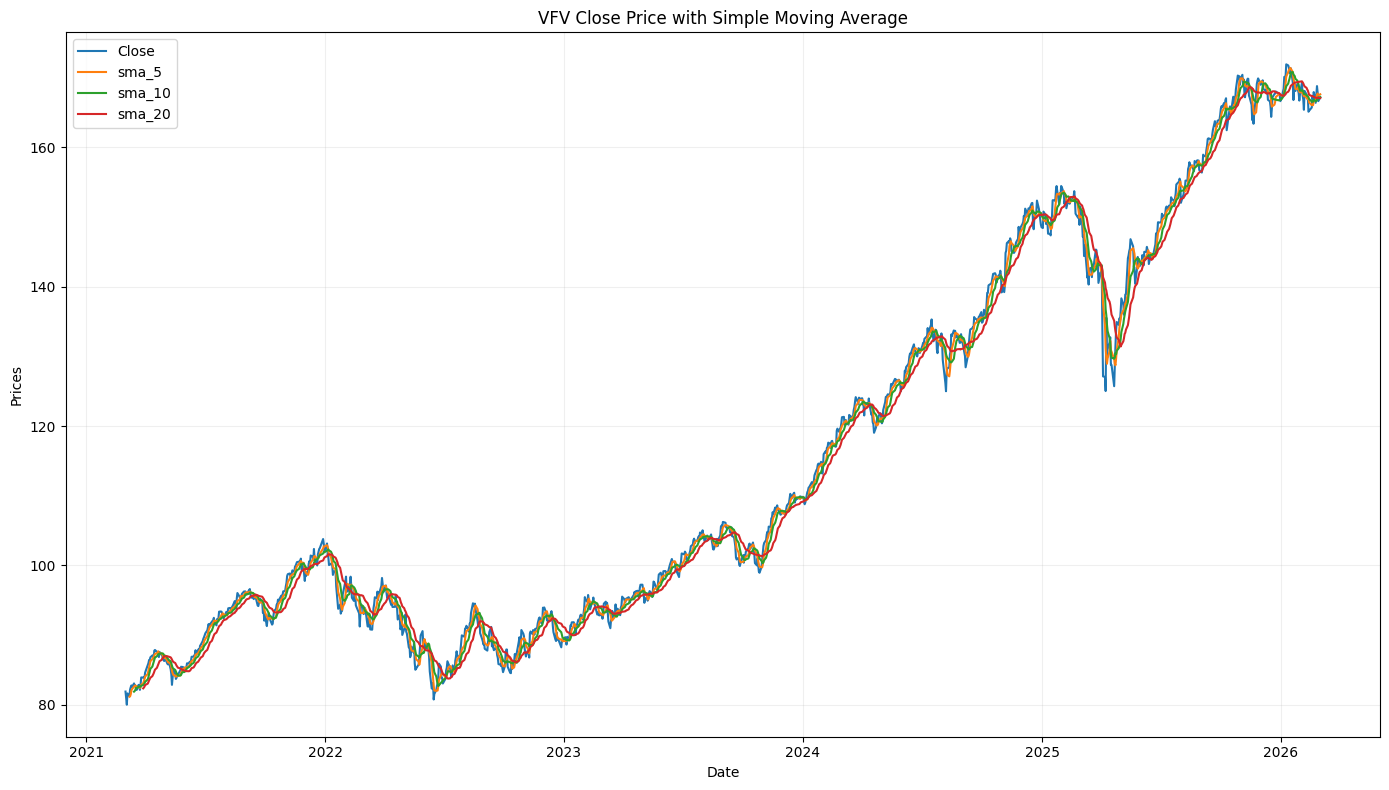

,Close,High,Low,Open,Volume,return_1day,return_5day,return_10day,return_20day,sma_5,sma_10,sma_20,close_ratio_amv_5,close_ratio_amv_10,close_ratio_amv_20
Date,,,,,,,,,,,,,,,
2021-03-02,81.894852,82.847558,81.894852,82.847558,182400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-03,81.008171,82.423079,81.008171,82.423079,185600,-0.010827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-04,80.008324,81.244008,79.263138,80.904429,311900,-0.012343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-05,81.630745,81.725071,79.470652,81.036486,263500,0.020278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-08,81.206261,82.347626,81.206261,82.064641,232800,-0.005200,NaN,NaN,NaN,81.149670,NaN,NaN,1.000697,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,167.639999,167.850006,166.179993,166.699997,282100,0.007573,0.011708,0.000358,-0.008517,167.212003,166.632002,167.065001,1.002560,1.006049,1.003442
2026-02-25,168.779999,168.919998,168.000000,168.000000,198100,0.006800,0.009208,0.010719,0.003568,167.520001,166.811002,167.095001,1.007521,1.011804,1.010084
2026-02-26,167.839996,169.000000,167.000000,168.919998,339800,-0.005569,0.005753,0.003708,0.000238,167.712000,166.873001,167.097001,1.000763,1.005795,1.004446


In [31]:
#Lagged Returns
for stock, dataframe in data.items():
    dataframe['return_1day'] = dataframe["Close"].pct_change(1)
    dataframe['return_5day'] = dataframe["Close"].pct_change(5)
    dataframe['return_10day'] = dataframe["Close"].pct_change(10)
    dataframe['return_20day'] = dataframe["Close"].pct_change(20)
    # print(f"--- {stock} ---")
    # print(dataframe[["Close", "return_1day", "return_5day", "return_10day", "return_20day"]].head(10))

#Simple Moving Average
for stock, dataframe in data.items():
    for day in [5, 10, 20]:
        simple_moving_average = f"sma_{day}"
        #we get the ratio of close and simple moving average to get the ratio so it normalizes our data 
        #in terms of the increase so $100 to $105 has the same impact as $3000 to $3005.
        close_ratio_amv = f"close_ratio_amv_{day}"
        dataframe[simple_moving_average] = dataframe["Close"].rolling(window=day).mean()
        dataframe[close_ratio_amv] = dataframe["Close"] / dataframe[simple_moving_average]
        print({stock})
        print(dataframe.head(6))
#VFV example
figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["Close"], label="Close")
for number in [5, 10, 20]:
    axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"][f"sma_{number}"], label=f"sma_{number}")
axis.set_title("VFV Close Price with Simple Moving Average")
axis.set_ylabel("Prices")
axis.set_xlabel("Date")
plt.tight_layout()
plt.legend()
axis.grid(True, alpha=0.2)
plt.show()
data["VFV_TO.csv"]

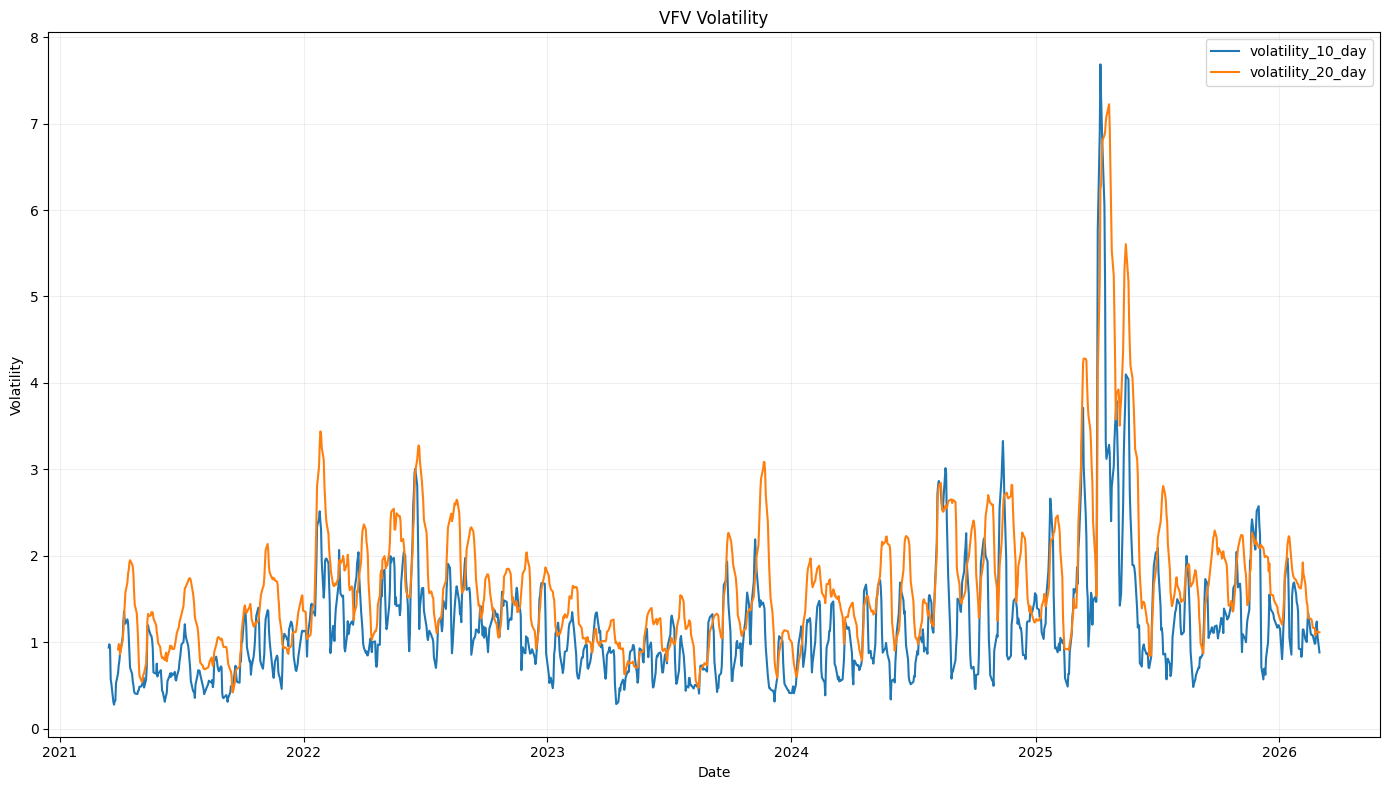

In [32]:
for stock, dataframe in data.items():
    dataframe["volatility_10_day"] = dataframe["Close"].rolling(window=10).std()
    dataframe["volatility_20_day"] = dataframe["Close"].rolling(window=20).std()
    
figure, axis = plt.subplots(figsize=(14, 8))
for number in [10, 20]:
    axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"][f"volatility_{number}_day"], label=f"volatility_{number}_day")
axis.grid(alpha=0.2)
axis.set_title("VFV Volatility")
axis.set_ylabel("Volatility")
axis.set_xlabel("Date")
plt.tight_layout()
plt.legend()
plt.show()


    
    